# Housing Market Simulation

This notebook runs a discrete-event housing market simulation and reconstructs
all analytics exclusively from the **event log**. A single landlord owns five
houses; renters enter the market exclusively through migration events and
compete for housing. Agents who remain homeless too long leave the system.

In [1]:
import os
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../..").resolve()))
os.environ["DISABLE_PANDERA_IMPORT_WARNING"] = "True"

from analytics import (
    AnalyticsPipeline,
    FeatherEngine,
    FrictionlessEngine,
    GoldTransformer,
    LOWESSSmoother,
    PersistenceManager,
    SilverTransformer,
    SmootherTransformer,
    Step,
)
from analytics.bronze import build_fact_table
from core import SimulationRunner, SimulationSettings, single_landlord_factory
from viz import DataVisualizer

d:\repositories\housing-market-simulation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Market Setup

- **Landlord** owns all five houses and earns no external income (lives off rent).
- There are **no initial renters**. Renters enter the system exclusively via
  migration events (`AgentEntered`) at random intervals.
- Entering agents start homeless and bid immediately on vacant houses.
- Agents who remain homeless for too long leave the system (`AgentLeft`).

The simulation is run **multiple times** (controlled by `N_RUNS`) to produce
confidence intervals that reflect simulation-level uncertainty.  LOWESS
smoothing can be toggled via the `SMOOTH_LOWESS` environment variable.

All parameters in `SimulationSettings` can be overridden with environment
variables (powered by *pydantic-settings*).

In [ ]:
settings = SimulationSettings(n_runs=20, max_t=200)
runner = SimulationRunner(settings=settings)

In [3]:
steps: list[Step] = [
    ("silver", SilverTransformer(time_resolution=settings.time_resolution, settings=settings)),
    ("gold", GoldTransformer()),
]
if settings.smooth_lowess:
    steps.append(("smooth", SmootherTransformer(LOWESSSmoother())))
pipeline = AnalyticsPipeline(steps=steps)

gold = pipeline.run(runner.run(single_landlord_factory))

Silver: 100%|██████████| 20/20 [26:03<00:00, 78.19s/it]


## Debug: Inspect a single run

The pipeline streams `RunResult` s straight from the runner, so individual
runs aren't retained in memory. To drop into the raw event log — e.g. when
a downstream plot like `plot_housed_renter_wealth` surfaces something
suspicious — simulate one additional run on demand and rebuild its bronze
fact table.

In [4]:
result = next(runner.run(single_landlord_factory))
facts = build_fact_table(result.event_log)
print(
    f"events={len(result.event_log)}  "
    f"t_max={facts['time'].max():.1f}"
)

events=115107  t_max=500.0


## Persistence

Gold tables are saved in two formats:

- **Feather** -- fast binary format for quick local reads/writes (git-ignored).
- **Frictionless Data Package** -- plain-text CSVs with a typed `datapackage.json`
  descriptor, suitable for version control, LLM analysis, and publishing.

In [5]:
output = Path("output")
persistence = PersistenceManager(engines=[FeatherEngine(), FrictionlessEngine()])
persistence.save(gold, output)

Persisting: 100%|██████████| 2/2 [00:00<00:00,  2.05it/s]


In [6]:
g_loaded = persistence.load(output, FeatherEngine())

In [7]:
viz = DataVisualizer(g_loaded, settings=settings)

## Visualizations

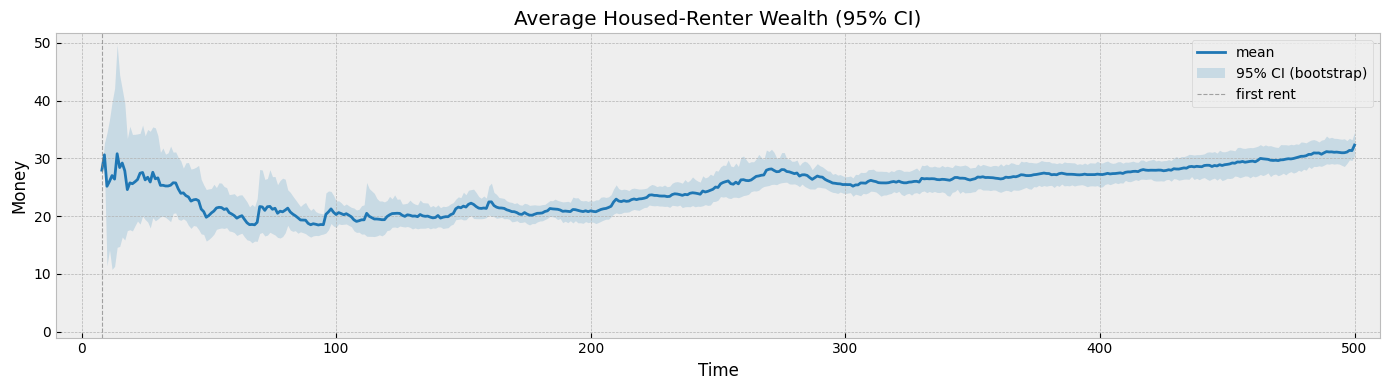

In [8]:
viz.plot_housed_renter_wealth()

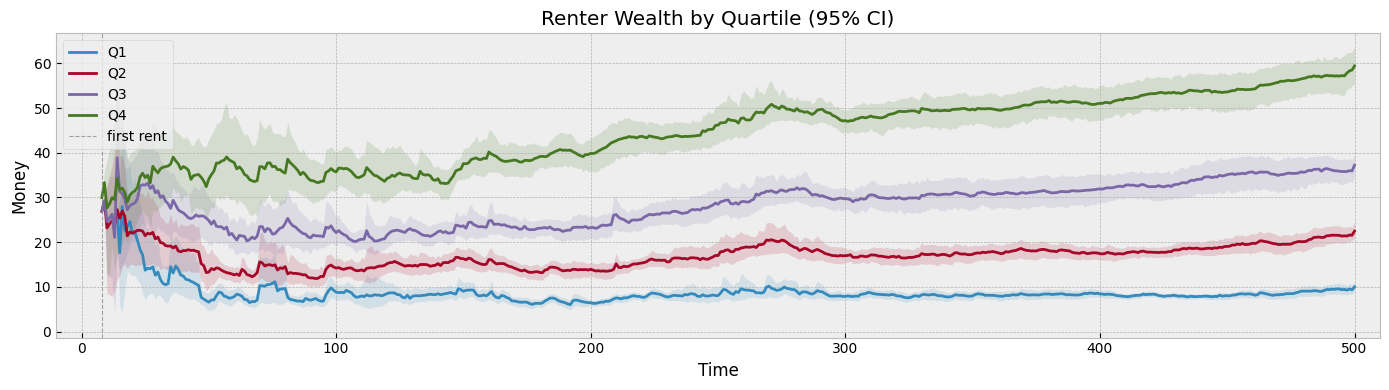

In [9]:
viz.plot_wealth_quartiles()

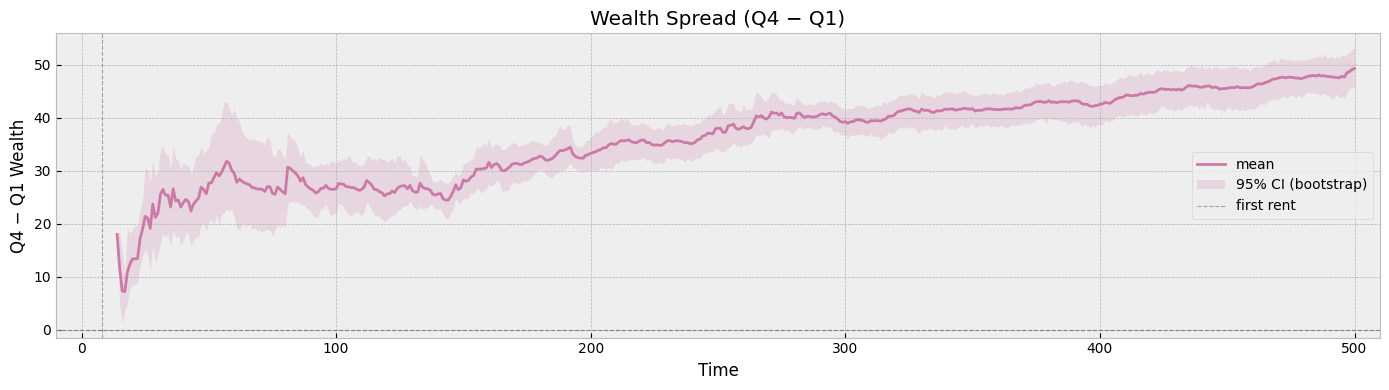

In [10]:
viz.plot_wealth_spread()

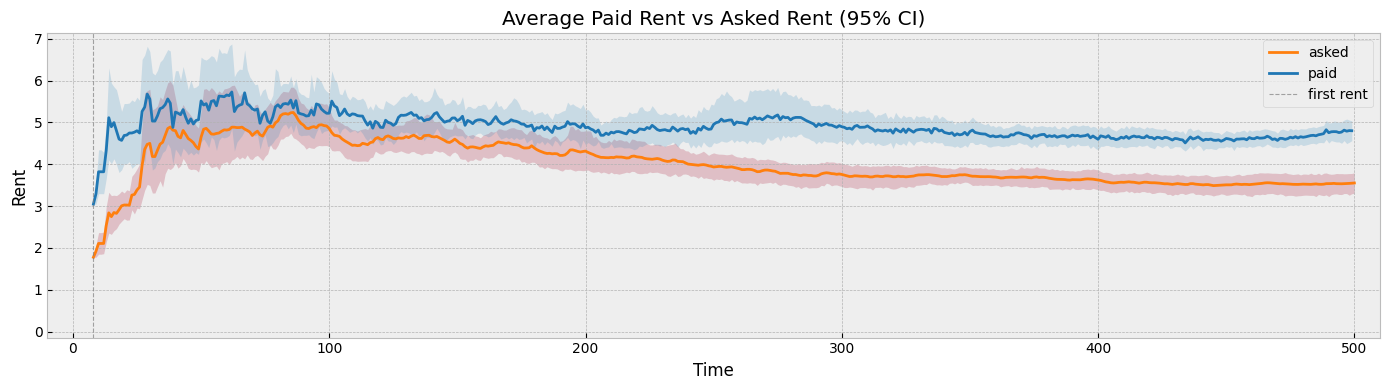

In [11]:
viz.plot_paid_vs_asked()

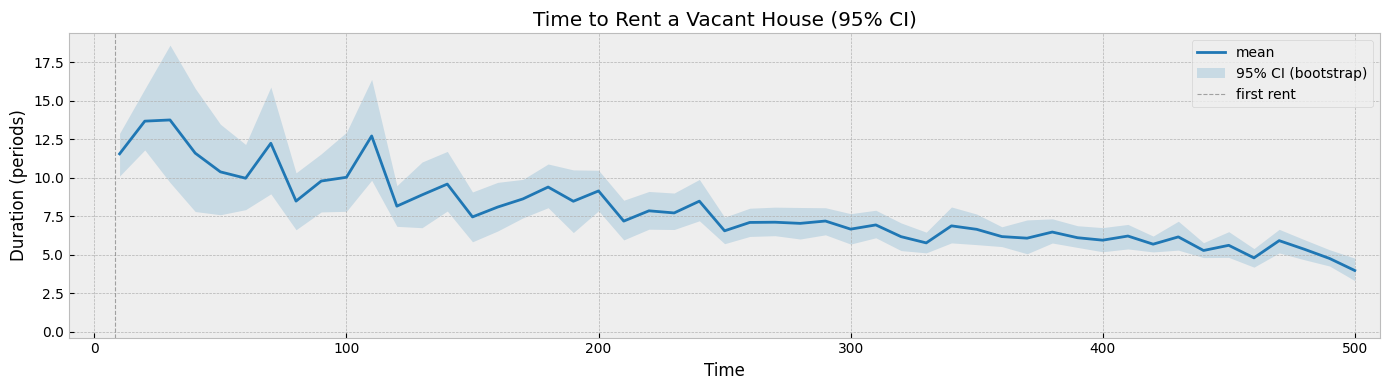

In [12]:
viz.plot_time_to_rent()

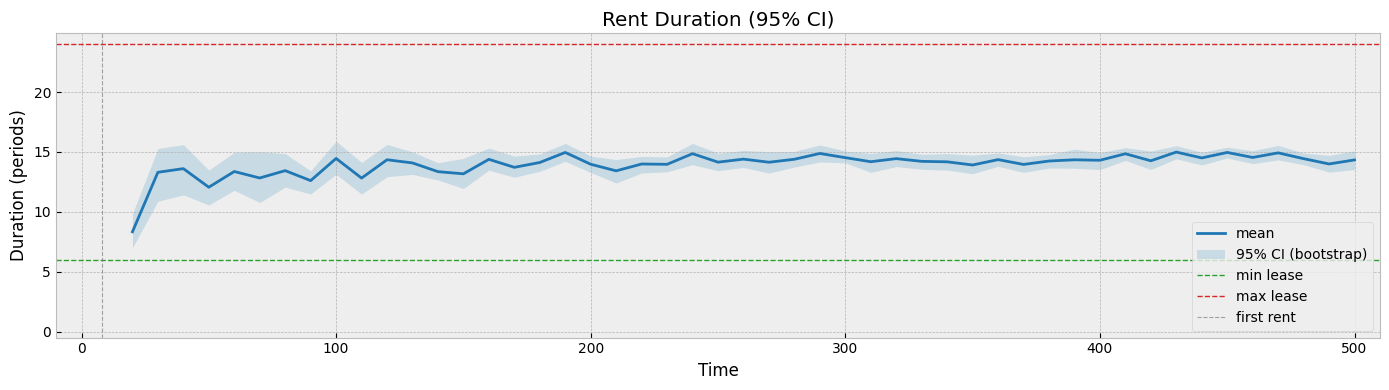

In [13]:
viz.plot_rent_duration()

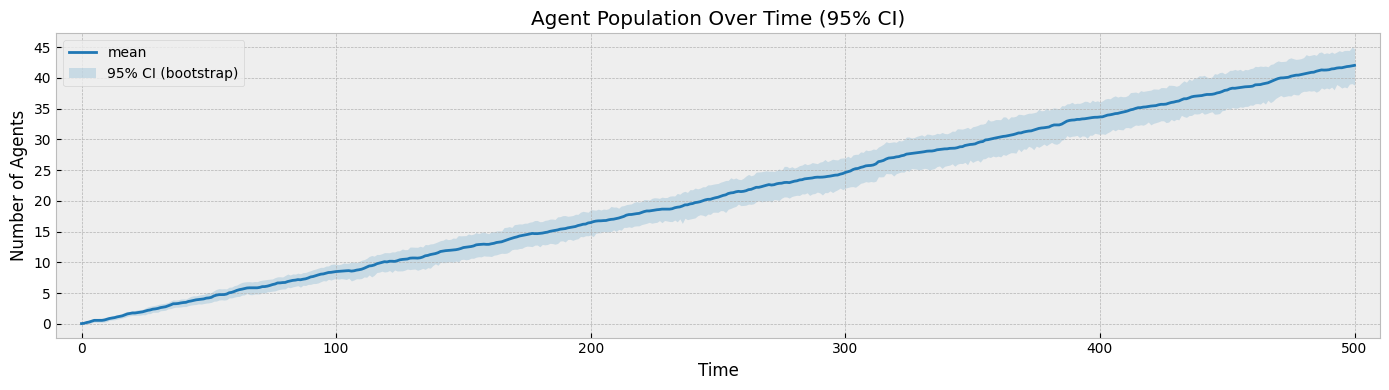

In [14]:
viz.plot_population()

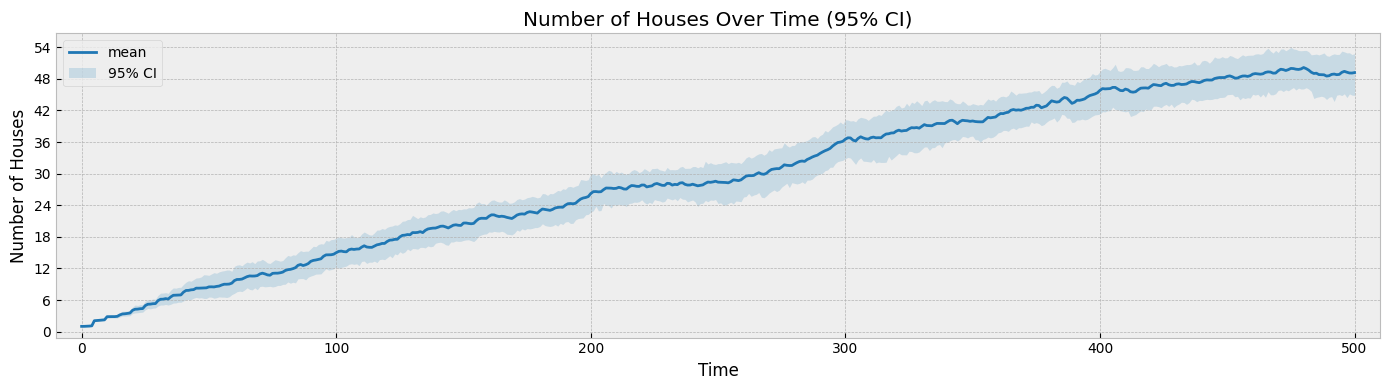

In [15]:
viz.plot_house_supply()

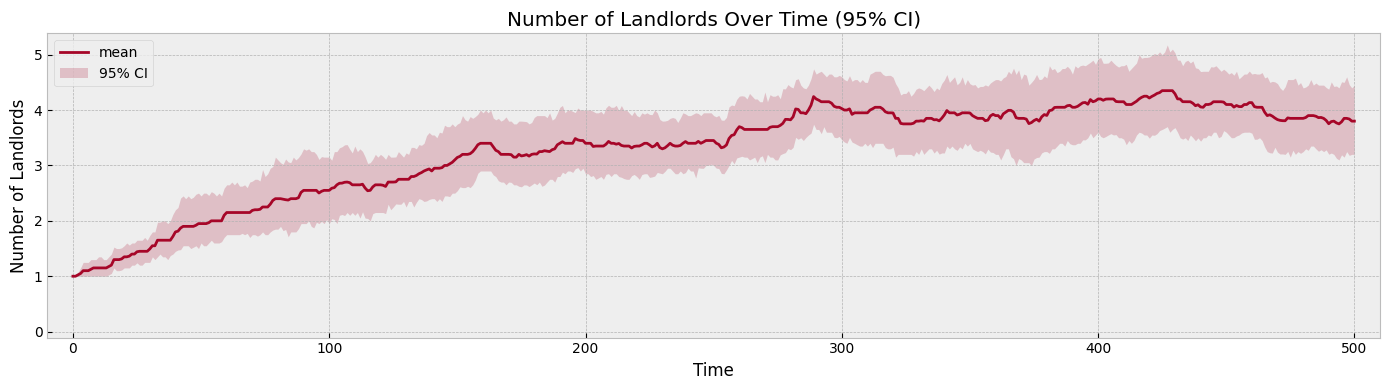

In [16]:
viz.plot_landlord_population()

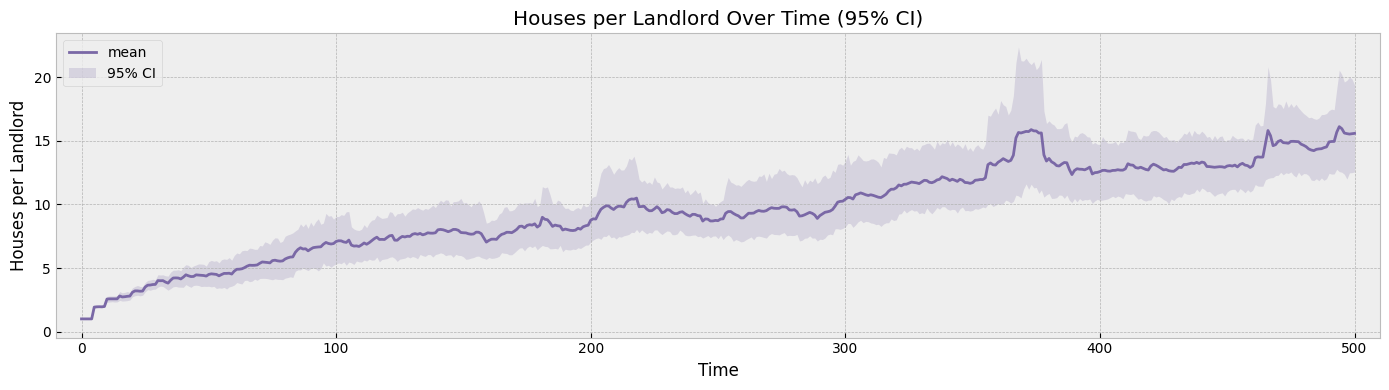

In [17]:
viz.plot_houses_per_landlord()

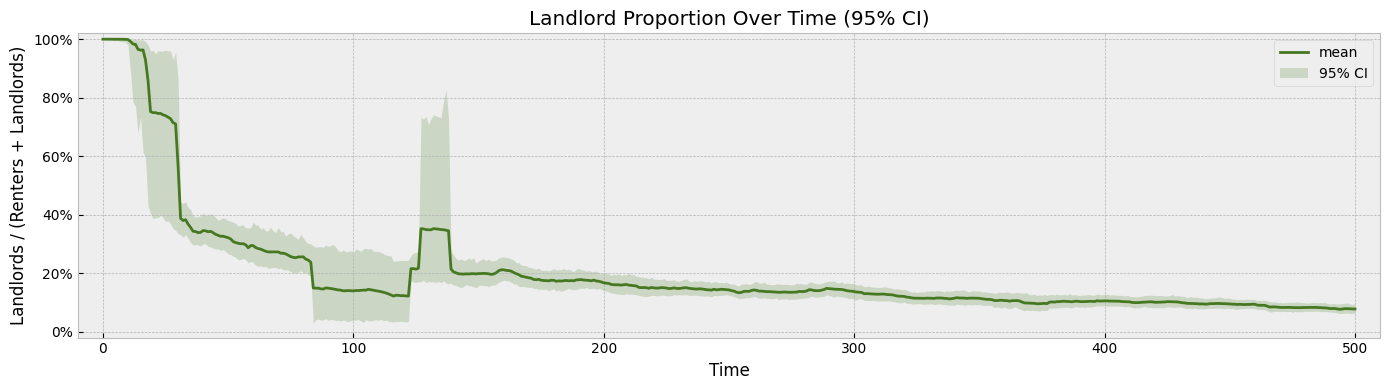

In [18]:
viz.plot_landlord_proportion()

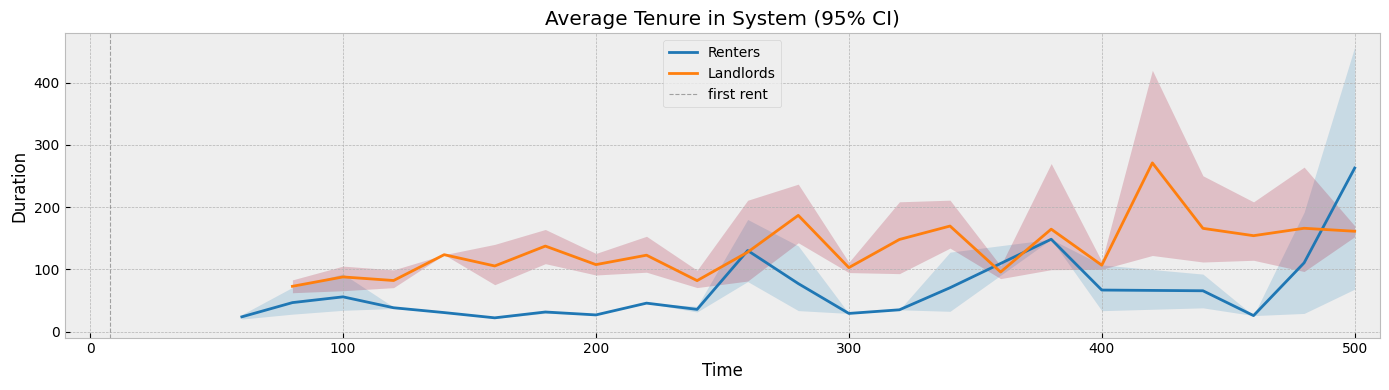

In [19]:
viz.plot_tenure()

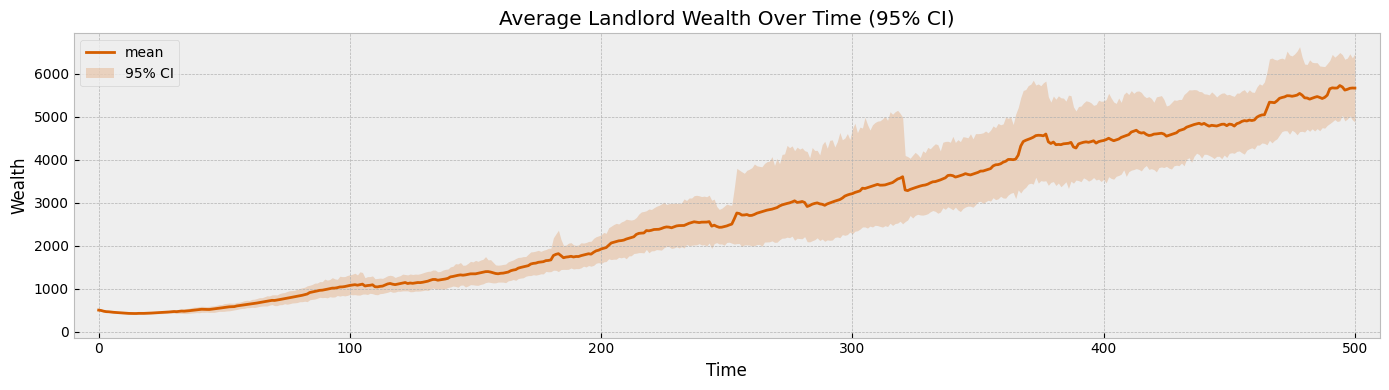

In [20]:
viz.plot_landlord_wealth()

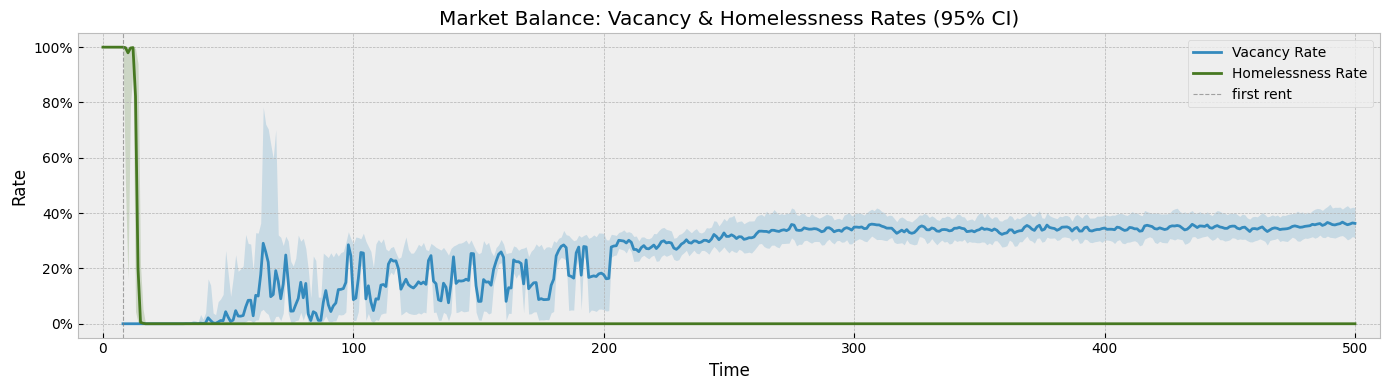

In [21]:
viz.plot_market_balance()

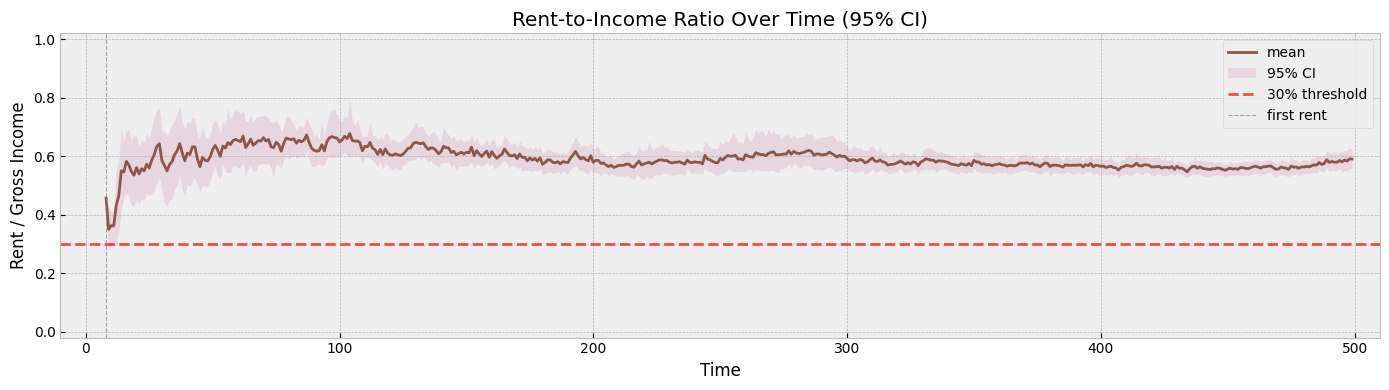

In [22]:
viz.plot_rent_to_income()

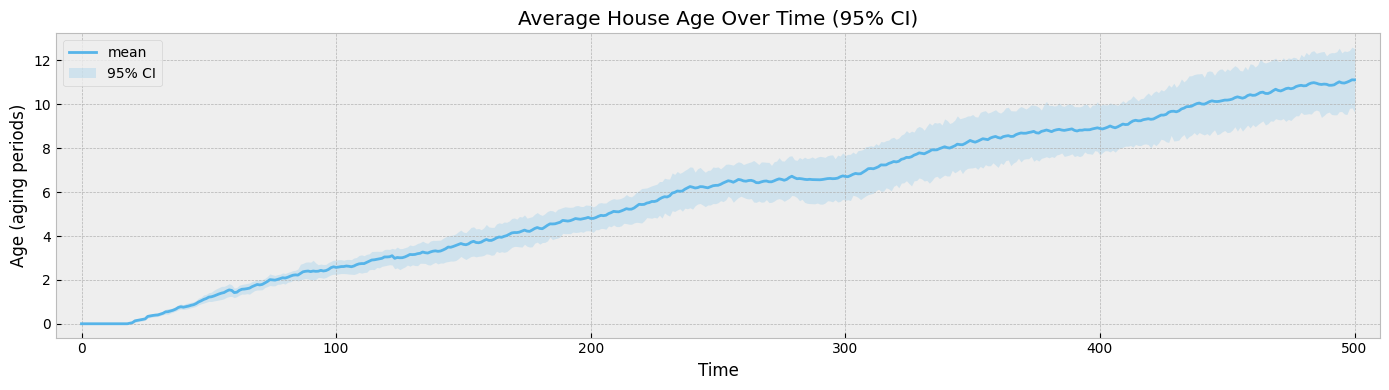

In [23]:
viz.plot_house_age()

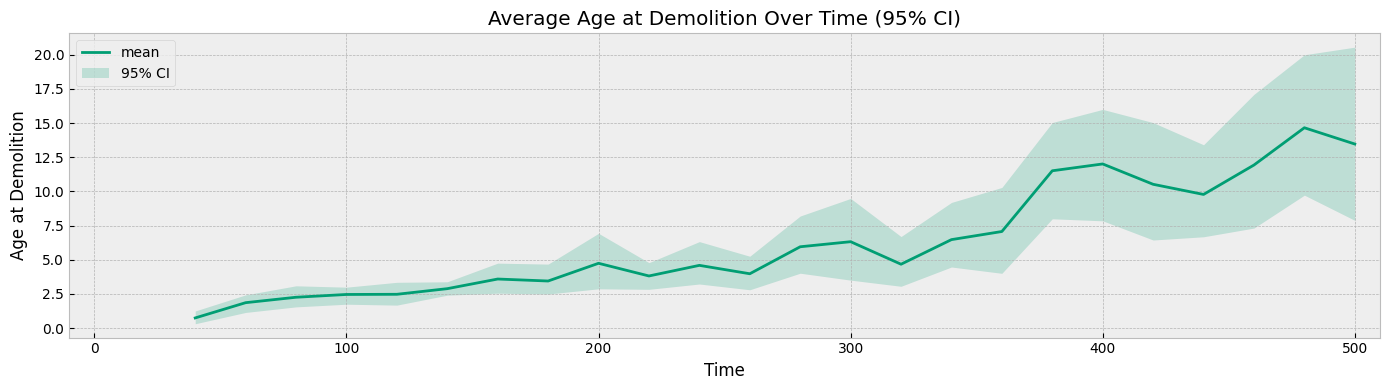

In [24]:
viz.plot_demolition_age()